# NETWORK MODELING FOR INFECTIOUS DISEASE SPREAD


– Causal Network Modeling
    - Gaussian Bayesian Network (GBN)

In [ ]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import BayesianRidge
from sklearn.metrics import (
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

## Data

In [ ]:
# Loading merged dataset
df = pd.read_csv("df_high_burden.csv")

# Sorting Data
df = df.sort_values(["state", "county", "year", "MMWR WEEK"])

df.head()


,state,county,year,MMWR WEEK,Label,previous_52_week_max,latitude,longitude,population_estimate,income,Label_grouped,Disease_Group
0,ALABAMA,Chilton,2022,1,"Arboviral diseases, West Nile virus disease",2,32.756889,-86.844516,45868.0,43434.0,Arboviral diseases,Vector-borne
1,ALABAMA,Chilton,2022,1,Campylobacteriosis,39,32.756889,-86.844516,45868.0,43434.0,Campylobacteriosis,Enteric
2,ALABAMA,Chilton,2022,1,Coccidioidomycosis,2,32.756889,-86.844516,45868.0,43434.0,Coccidioidomycosis,Fungal
3,ALABAMA,Chilton,2022,1,Cryptosporidiosis,7,32.756889,-86.844516,45868.0,43434.0,Cryptosporidiosis,Enteric
4,ALABAMA,Chilton,2022,1,Cyclosporiasis,3,32.756889,-86.844516,45868.0,43434.0,Cyclosporiasis,Enteric


In [ ]:
# Checking Data Structure
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 174042 entries, 0 to 174041
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   state                 174042 non-null  object 
 1   county                174042 non-null  object 
 2   year                  174042 non-null  int64  
 3   MMWR WEEK             174042 non-null  int64  
 4   Label                 174042 non-null  object 
 5   previous_52_week_max  174042 non-null  int64  
 6   latitude              174042 non-null  float64
 7   longitude             174042 non-null  float64
 8   population_estimate   174042 non-null  float64
 9   income                174042 non-null  float64
 10  Label_grouped         174042 non-null  object 
 11  Disease_Group         174042 non-null  object 
dtypes: float64(4), int64(3), object(5)
memory usage: 15.9+ MB


In [ ]:
# Data Pre-processing

# Log Transformation for Target
df["previous_52_week_max"]= np.log1p(df["previous_52_week_max"].values).astype(np.float32)

# Dropping geographic coordinates
df_gbn = df.copy()

df_gbn = df_gbn.drop(
    columns=["latitude", "longitude","year","Label","Disease_Group"]
)


In [ ]:
# Target and Creating Lags

target = "previous_52_week_max"

df_gbn["lag_1"] = df_gbn.groupby(["state", "county"])[target].shift(1)
df_gbn["lag_2"] = df_gbn.groupby(["state", "county"])[target].shift(2)
df_gbn["lag_3"] = df_gbn.groupby(["state", "county"])[target].shift(3)
df_gbn["lag_4"] = df_gbn.groupby(["state", "county"])[target].shift(4)

# Dropping NaNs
df_gbn = df_gbn.dropna()

## Data Partitioning

In [ ]:
# Splitting data into train and test using 80/20 split
train_df, test_df = train_test_split(
    df_gbn,
    test_size=0.25,
    random_state=42
)

print(train_df.shape, test_df.shape)


(130270, 11) (43424, 11)


In [ ]:
# One-Hot Encoding
from sklearn.preprocessing import OneHotEncoder
import pandas as pd

categorical_cols = train_df.select_dtypes(include=["object"]).columns

ohe = OneHotEncoder(
    handle_unknown="ignore",
    sparse_output=False
)

# Fitting on train and transforming test
train_cat = ohe.fit_transform(train_df[categorical_cols])
test_cat = ohe.transform(test_df[categorical_cols])

# Converting to dataframe
train_cat_df = pd.DataFrame(
    train_cat,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=train_df.index
)

test_cat_df = pd.DataFrame(
    test_cat,
    columns=ohe.get_feature_names_out(categorical_cols),
    index=test_df.index
)

# Dropping Original Columns
train_num = train_df.drop(columns=categorical_cols)
test_num = test_df.drop(columns=categorical_cols)

# Combining with numeric variables
train_df = pd.concat([train_num, train_cat_df], axis=1)
test_df = pd.concat([test_num, test_cat_df], axis=1)

## Gaussian Bayesian Network (GBN)

In [ ]:
# Parents
parents = [col for col in train_df.columns if col != target]

In [ ]:
# Splitting target and parents in causal relationship
X_train = train_df[parents]

y_train = train_df[target]


In [ ]:
# Fitting Model
gbn_target = BayesianRidge(alpha_1=1e-7,
    alpha_2=1e-7,
    lambda_1=1e-7,
    lambda_2=1e-7)

gbn_target.fit(
    X_train,
    y_train
)

,max_iter,300
,tol,0.001
,alpha_1,1e-07
,alpha_2,1e-07
,lambda_1,1e-07
,lambda_2,1e-07
,alpha_init,None
,lambda_init,None
,compute_score,False
,fit_intercept,True
,copy_X,True


### Predictions

In [ ]:
# Test set predictions

# Splitting target and parents in causal relationship
X_test = test_df[parents]

y_test = test_df[
    "previous_52_week_max"
]

# Prediction
y_pred = gbn_target.predict(
    X_test
)

### Model Evaluation

In [ ]:
# Performance Metrics
rmse = np.sqrt(
    mean_squared_error(
        y_test,
        y_pred
    )
)

mae = mean_absolute_error(
    y_test,
    y_pred
)

r2 = r2_score(
    y_test,
    y_pred
)

print(f"RMSE : {rmse:.3f}")
print(f"MAE  : {mae:.3f}")
print(f"R²   : {r2:.3f}")

RMSE : 0.760
MAE  : 0.587
R²   : 0.708


### Feature Importance


Aggregated Feature Importance:

BaseFeature
population_estimate    3.698510e-10
income                 1.370809e-05
MMWR WEEK              1.920799e-03
lag_2                  1.076366e-02
lag_4                  2.081537e-02
lag_1                  3.889240e-02
lag_3                  5.252701e-02
county                 1.926862e-01
state                  2.766404e-01
Label_grouped          9.257388e-01
Name: AbsCoeff, dtype: float64


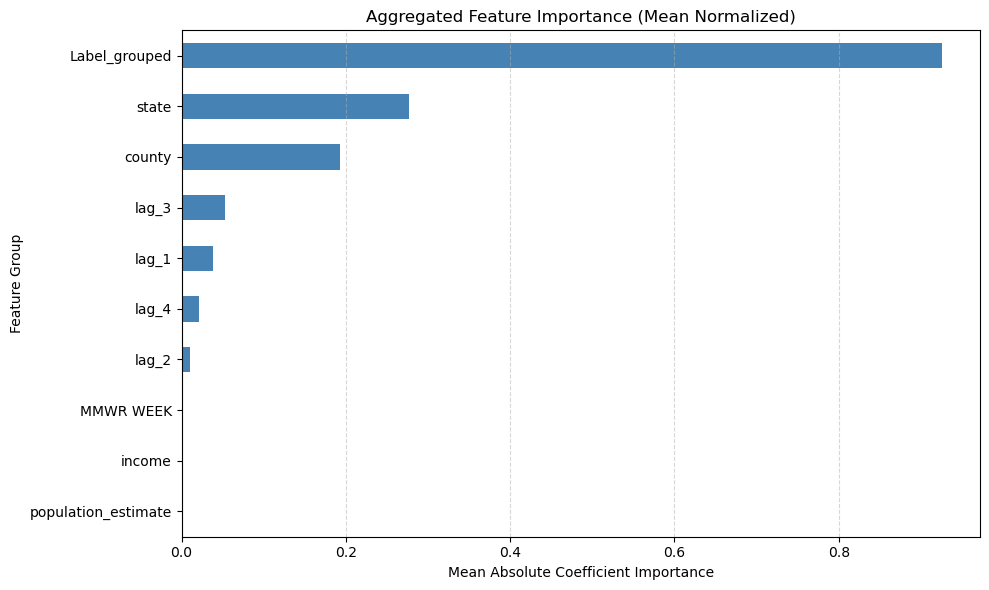

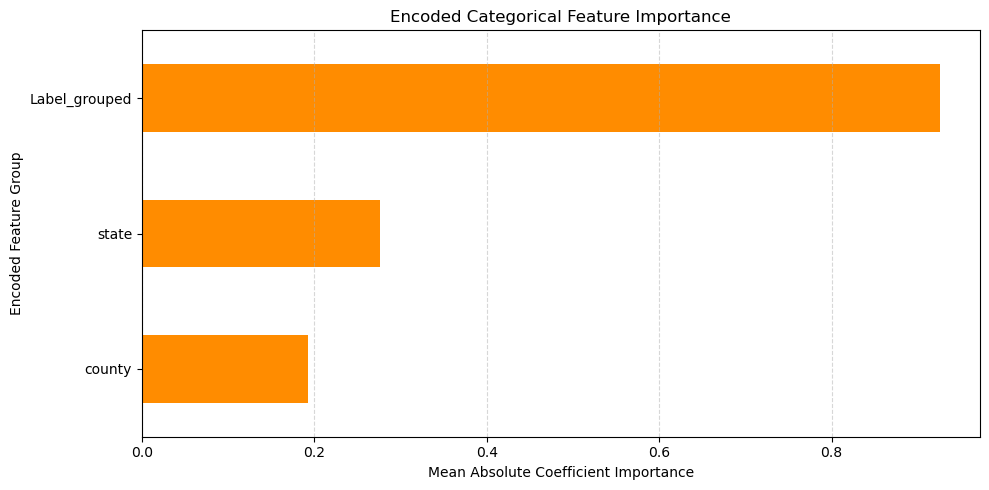

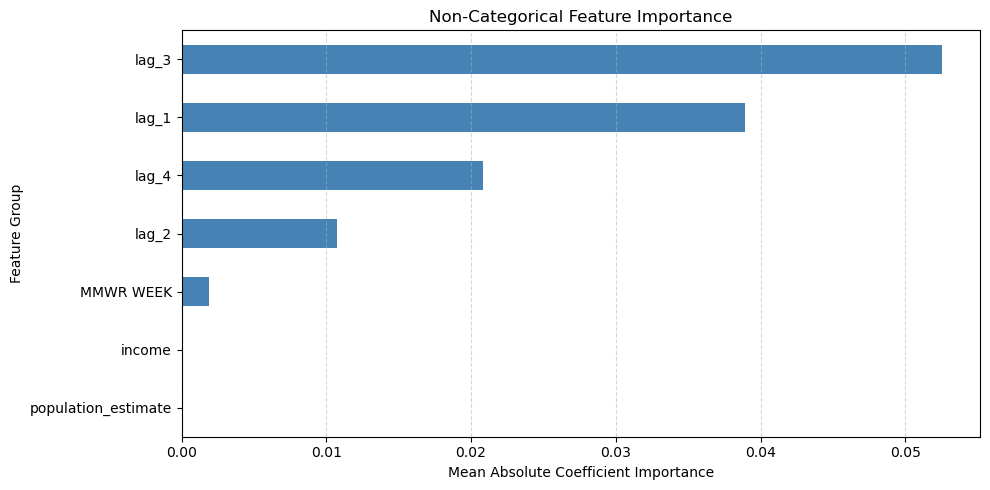

In [ ]:
import matplotlib.pyplot as plt

# Building raw coefficient table

importance = pd.DataFrame({
    "Feature": parents,
    "Coefficient": gbn_target.coef_
})

importance["AbsCoeff"] = importance["Coefficient"].abs()

# Mapping one-hot features back to base features

def map_base_feature(f):
    if f.startswith("state_"):
        return "state"
    elif f.startswith("county_"):
        return "county"
    elif f.startswith("Label_grouped_"):
        return "Label_grouped"
    else:
        return f

importance["BaseFeature"] = importance["Feature"].apply(map_base_feature)

# Aggregating importance

agg_importance = importance.groupby("BaseFeature")["AbsCoeff"].mean().sort_values(ascending=True)

print("\nAggregated Feature Importance:\n")
print(agg_importance)

# Plot

plt.figure(figsize=(10, 6))

# Normalizing importance by number of dummy variables per group
agg_importance_mean = importance.groupby("BaseFeature")["AbsCoeff"].mean().sort_values(ascending=True)

agg_importance_mean.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Aggregated Feature Importance (Mean Normalized)")
plt.xlabel("Mean Absolute Coefficient Importance")
plt.ylabel("Feature Group")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Separate encoded categorical vs other features

encoded_mask = importance["Feature"].str.startswith("state_") | \
               importance["Feature"].str.startswith("county_") | \
               importance["Feature"].str.startswith("Label_grouped_")

encoded_importance = importance[encoded_mask].copy()
other_importance = importance[~encoded_mask].copy()

# Aggregate encoded categorical variables

encoded_agg = encoded_importance.groupby("BaseFeature")["AbsCoeff"].mean().sort_values()

# Aggregate remaining features

other_agg = other_importance.groupby("BaseFeature")["AbsCoeff"].mean().sort_values()

# Plot encoded categorical variables

plt.figure(figsize=(10, 5))

encoded_agg.plot(
    kind="barh",
    color="darkorange"
)

plt.title("Encoded Categorical Feature Importance")
plt.xlabel("Mean Absolute Coefficient Importance")
plt.ylabel("Encoded Feature Group")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()

# Plot remaining features

plt.figure(figsize=(10, 5))

other_agg.plot(
    kind="barh",
    color="steelblue"
)

plt.title("Non-Categorical Feature Importance")
plt.xlabel("Mean Absolute Coefficient Importance")
plt.ylabel("Feature Group")
plt.grid(axis="x", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.show()